# 01 - Exploración Inicial del Dataset de Reservas Hoteleras
## Hotel Dann Monasterio - Periodo junio 2020 a abril 2026

## Objetivo del notebook
Realizar una exploración inicial del dataset de reservas del Hotel Dann Monasterio para comprender:

- Estructura general de los datos (filas, columnas, tipos).
- Calidad de los datos (valores nulos, duplicados, columnas vacías).
- Estadísticas descriptivas básicas de las variables numéricas.
- Variables con significado claro, parcial o desconocido.
- Distribución de las variables categóricas clave del proyecto (segmento, canal, plan, temporada, tipo de habitación).
- Distribución de las variables numéricas clave (tarifa, ingresos, edad).
- Detección preliminar de valores atípicos.

## Contexto
Este notebook es la primera etapa del flujo CRISP-DM dentro del proyecto: corresponde a la fase **Comprensión de los Datos**. Su salida alimenta los notebooks 02 (limpieza) y 03 (EDA).

## Importar librerías

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración visual
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

In [32]:
# ── Carpeta de figuras ─────────────────────────────────────────────────────
# Todas las gráficas generadas en este notebook se guardan automáticamente
# en reports/figures/ para que sirvan como evidencia del EDA en el
# documento académico y en el informe de calidad de datos.
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figuras se guardarán en: {FIG_DIR.resolve()}")


Figuras se guardarán en: D:\FelipeMutis\DocumentosPersonales\8.University\Diplomado\ProyectoFinal\project_develop\SoluciónAnalíticaDeDatosParaHotel\proyecto_analitica_hotel\reports\figures


## Cargar dataset

Ruta del archivo fuente:  
`proyecto_analitica_hotel/data/raw/DataSet_ReservaYHuespedes_V01.xlsx`

El archivo contiene dos hojas (`Hoja1` y `Hoja2`) con la misma estructura de 79 columnas. El código soporta todos los casos, si el archivo tiene 2 o mas hojas las va a leer bien y va a retornar el total de datos en un dataframe.

In [33]:
ruta = Path("../data/raw/DataSet_ReservaYHuespedes_V01.xlsx")

# Lee todas las hojas automáticamente
hojas = pd.read_excel(ruta, sheet_name=None)

# Mostrar shape por hoja
for nombre, df_hoja in hojas.items():
    print(f"{nombre}: {df_hoja.shape}")

if len(hojas) == 1:
    df = next(iter(hojas.values())).copy()
else:
    df = pd.concat(hojas.values(), ignore_index=True)

print(f"Consolidado: {df.shape}")
df.head()

Hoja1: (65534, 79)
Hoja2: (5348, 79)
Consolidado: (70882, 79)


,fecha,codigp_pla_reg,consecut,codigp_pla,codsegmento,codmotivacion,ident_aco,tdcto_aco_his,clasi_aco_his,idn_aco_his,codigoclase_his,nrohab_hab_his,foliotitular_his,nfolio_his,codigoprogramacliente,registro,nfolio,nombre_aco,tdcto_aco,fllega_aco,fsalid_aco,porce_aco,vlr_aco,clasi_aco,nrohab_hab,nfolor_aco,idn_aco,estado_aco,adici_aco,edad_aco,sexo_aco,adicmaex,fcheckout,usuchout,numvoucher,descri_pla,nreser_res,codofic,adultos,ninos,adicionales,nombre_emp,tarifa,adicional,nacionalidad,oficio,alimen_pla,incognito,fechasischin,campo1,campo2,campo3,codiga_age,nombre_age,tiphab_tip,complejo,descricomplejo,codigoclase,descripcionclase,vlrus_red,us_reg,orden,descripcionorden,valorplan,ivaplan,servicioplan,valorconsumoadicional,ivaconsumoadicional,servicioconsumoadicional,totalconsumosplan,totalconsumosadicional,codigocategoria,nombrecategoria,clahab_clh,codigotemporada,nombretemporada,folio_titular,folio_maestro,tipofolio
0,2020.06.01,CORP1,114472,CORP1,COR,CCE,1075659763,CE,A,T,NaN,207,NaN,93022.0,NaN,78039,93022.0,ROZO HERNANDEZ DARIO ALEXANDER,CE,2020-06-01,2020-06-02,0,0,A,207,93022.0,T,32,N,36,M,NaN,2020-06-02,JEFERSON,75523,CORPORATIVO 1,NaN,NaN,NaN,NaN,NaN,J RESTREPO EQUIPHOS SAS,183800.0,70000.0,COL,165.0,S,N,2020-06-10 18:56:00.000,NaN,NaN,NaN,NaN,NaN,SE,HOTEL,HOTEL DANN MONASTERI,NaN,NaN,0.0,P,NaN,NaN,190000.0,36100.0,0.0,0.0,0.0,0.0,226100.0,0.0,NaN,No Definida,SG,NaN,NaN,93022,93022,H
1,2020.06.10,CORP1,114473,CORP1,COR,CCE,1075659763,CE,A,T,NaN,207,NaN,93023.0,NaN,78040,93023.0,ROZO HERNANDEZ DARIO ALEXANDER,CE,2020-06-10,2020-06-11,0,0,A,207,93023.0,T,32,N,36,M,NaN,2020-06-11,JEFERSON,75524,CORPORATIVO 1,NaN,NaN,NaN,NaN,NaN,J RESTREPO EQUIPHOS SAS,183800.0,70000.0,COL,165.0,S,N,2020-06-11 15:29:00.000,NaN,NaN,NaN,NaN,NaN,SE,HOTEL,HOTEL DANN MONASTERI,NaN,NaN,0.0,P,NaN,NaN,190000.0,36100.0,0.0,0.0,0.0,0.0,226100.0,0.0,NaN,No Definida,SG,NaN,NaN,93023,93023,H
2,2020.06.11,CORP1,114474,CORP1,COR,CCE,1112099164,CE,A,T,NaN,207,NaN,93025.0,NaN,78041,93025.0,PEREZ MONTOYA CARLOS AUGUSTO,CE,2020-06-11,2020-06-12,0,0,A,207,93025.0,T,32,N,126,M,NaN,2020-06-12,AESTRADA,75525,CORPORATIVO 1,NaN,NaN,NaN,NaN,NaN,KELLOGG DE COLOMBIA S.A.,183800.0,70000.0,COL,96.0,S,N,2020-06-12 07:16:00.000,NaN,NaN,NaN,NaN,NaN,SE,HOTEL,HOTEL DANN MONASTERI,NaN,NaN,0.0,P,NaN,NaN,190000.0,36100.0,0.0,0.0,0.0,0.0,226100.0,0.0,NaN,No Definida,SG,NaN,NaN,93025,93025,H
3,2020.07.02,CORP1,114475,CORP1,COR,CCE,16842997,CE,A,T,NaN,207,NaN,93030.0,NaN,78042,93030.0,GARZON PARRA OSCAR JULIAN,CE,2020-07-02,2020-07-18,0,0,A,207,93030.0,T,32,N,45,M,NaN,2020-07-18,AESTRADA,75526,CORPORATIVO 1,70660.0,2.0,NaN,NaN,NaN,CEMENTOS ARGOS S.A,183800.0,70000.0,COL,165.0,S,N,2020-07-03 08:19:59.999,NaN,NaN,NaN,AVIA,AVIATUR,SE,HOTEL,HOTEL DANN MONASTERI,NaN,NaN,0.0,P,NaN,NaN,190000.0,0.0,0.0,0.0,0.0,0.0,190000.0,0.0,NaN,No Definida,SG,NaN,NaN,93030,93030,H
4,2020.07.03,CORP1,114475,CORP1,COR,CCE,16842997,CE,A,T,NaN,207,NaN,93030.0,NaN,78042,93030.0,GARZON PARRA OSCAR JULIAN,CE,2020-07-02,2020-07-18,0,0,A,207,93030.0,T,32,N,45,M,NaN,2020-07-18,AESTRADA,75526,CORPORATIVO 1,70660.0,2.0,NaN,NaN,NaN,CEMENTOS ARGOS S.A,183800.0,70000.0,COL,165.0,S,N,2020-07-03 08:19:59.999,NaN,NaN,NaN,AVIA,AVIATUR,SE,HOTEL,HOTEL DANN MONASTERI,NaN,NaN,0.0,P,NaN,NaN,190000.0,0.0,0.0,0.0,0.0,0.0,190000.0,0.0,NaN,No Definida,SG,NaN,NaN,93030,93030,H


## Información general

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70882 entries, 0 to 70881
Data columns (total 79 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     70882 non-null  object        
 1   codigp_pla_reg            70882 non-null  object        
 2   consecut                  70882 non-null  int64         
 3   codigp_pla                70882 non-null  object        
 4   codsegmento               70882 non-null  object        
 5   codmotivacion             70882 non-null  object        
 6   ident_aco                 70882 non-null  object        
 7   tdcto_aco_his             70882 non-null  object        
 8   clasi_aco_his             70882 non-null  object        
 9   idn_aco_his               70882 non-null  object        
 10  codigoclase_his           0 non-null      float64       
 11  nrohab_hab_his            70882 non-null  int64         
 12  foliotitular_his  

## Dimensiones del dataset

In [35]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

Filas: 70,882
Columnas: 79


## Tipos de variables

Conteo de columnas por tipo de dato:

In [36]:
df.dtypes.value_counts()

object            33
float64           31
int64             11
datetime64[ns]     4
Name: count, dtype: int64

Listado completo de columnas con su tipo de dato:

In [37]:
# Mostrar tipos de datos ordenados sin poder expandir...
#df.dtypes.sort_values()

# Mostrar lista completa de los datos ordenados..
print(df.dtypes.sort_values().to_string())

folio_maestro                        int64
estado_aco                           int64
fcheckout                   datetime64[ns]
nrohab_hab                           int64
vlr_aco                              int64
porce_aco                            int64
numvoucher                           int64
registro                             int64
nrohab_hab_his                       int64
edad_aco                             int64
folio_titular                        int64
consecut                             int64
adicional                          float64
adicmaex                           float64
campo2                             float64
descripcionorden                   float64
campo1                             float64
fechasischin                datetime64[ns]
codigoclase                        float64
orden                              float64
nreser_res                         float64
codofic                            float64
adultos                            float64
descripcion

## Verificar valores nulos

Se construye una tabla resumen con la cantidad y el porcentaje de nulos por columna, ordenada de mayor a menor.

In [38]:
nulos = df.isnull().sum()
porc  = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "nulos": nulos,
    "% nulos": porc,
    "no_nulos": df.notnull().sum()
}).sort_values("% nulos", ascending=False)

#resumen_nulos
print(resumen_nulos.to_string())

                          nulos  % nulos  no_nulos
codigoclase_his           70882   100.00         0
codigoprogramacliente     70882   100.00         0
descripcionclase          70882   100.00         0
descripcionorden          70882   100.00         0
codigocategoria           70882   100.00         0
codigoclase               70882   100.00         0
adicmaex                  70882   100.00         0
campo1                    70882   100.00         0
orden                     70882   100.00         0
ninos                     70866    99.98        16
adultos                   70866    99.98        16
adicionales               70866    99.98        16
campo3                    70672    99.70       210
campo2                    70637    99.65       245
oficio                    68303    96.36      2579
foliotitular_his          45149    63.70     25733
codigotemporada           37760    53.27     33122
nombretemporada           37760    53.27     33122
nfolio_his                25733

### Columnas con 100% de valores nulos

Estas columnas no aportan información y se eliminarán en la etapa de limpieza.

In [39]:
cols_100_nulas = resumen_nulos[resumen_nulos["% nulos"] == 100].index.tolist()
print(f"Total de columnas 100% nulas: {len(cols_100_nulas)}")
cols_100_nulas

Total de columnas 100% nulas: 9


['codigoclase_his',
 'codigoprogramacliente',
 'descripcionclase',
 'descripcionorden',
 'codigocategoria',
 'codigoclase',
 'adicmaex',
 'campo1',
 'orden']

## Columnas sin variabilidad (un único valor)

Identificamos las columnas que tienen un único valor en todo el dataset - no aportan información discriminante.

In [40]:
unicos_por_col = df.nunique(dropna=True)
cols_un_valor = unicos_por_col[unicos_por_col == 1].index.tolist()
print(f"Total columnas con un único valor: {len(cols_un_valor)}\n")

for c in cols_un_valor:
    print(f"{c}: {df[c].dropna().unique()}")

Total columnas con un único valor: 10

porce_aco: [0]
vlr_aco: [0]
adici_aco: ['N']
ninos: [0.]
adicionales: [0.]
complejo: ['HOTEL']
descricomplejo: ['HOTEL DANN MONASTERI']
us_reg: ['P']
nombrecategoria: ['No Definida']
tipofolio: ['H']


## Mapa de calidad de datos — nulos y variabilidad

La siguiente gráfica consolida en una sola vista el estado de **todas las variables** del dataset en dos dimensiones de calidad:

- **Valores nulos (%)**: proporción de registros sin dato para cada columna. Las barras se colorean en tres rangos: verde (< 5 %), naranja (5 – 99 %) y rojo (= 100 %).
- **Sin variabilidad**: columnas marcadas con ★ cuyo único valor no aporta información discriminante al modelo.

El resultado se guarda como `reports/figures/00_calidad_datos.png` para incorporarlo como evidencia en el documento académico.

Variables con algún problema de calidad: 36 / 79


C:\Users\Luis Mutis\AppData\Local\Temp\ipykernel_35248\122492789.py:90: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Luis Mutis\AppData\Local\Temp\ipykernel_35248\122492789.py:91: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / "00_calidad_datos.png", bbox_inches='tight', dpi=150)
d:\FelipeMutis\DocumentosPersonales\8.University\Diplomado\ProyectoFinal\project_develop\SoluciónAnalíticaDeDatosParaHotel\proyecto_analitica_hotel\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


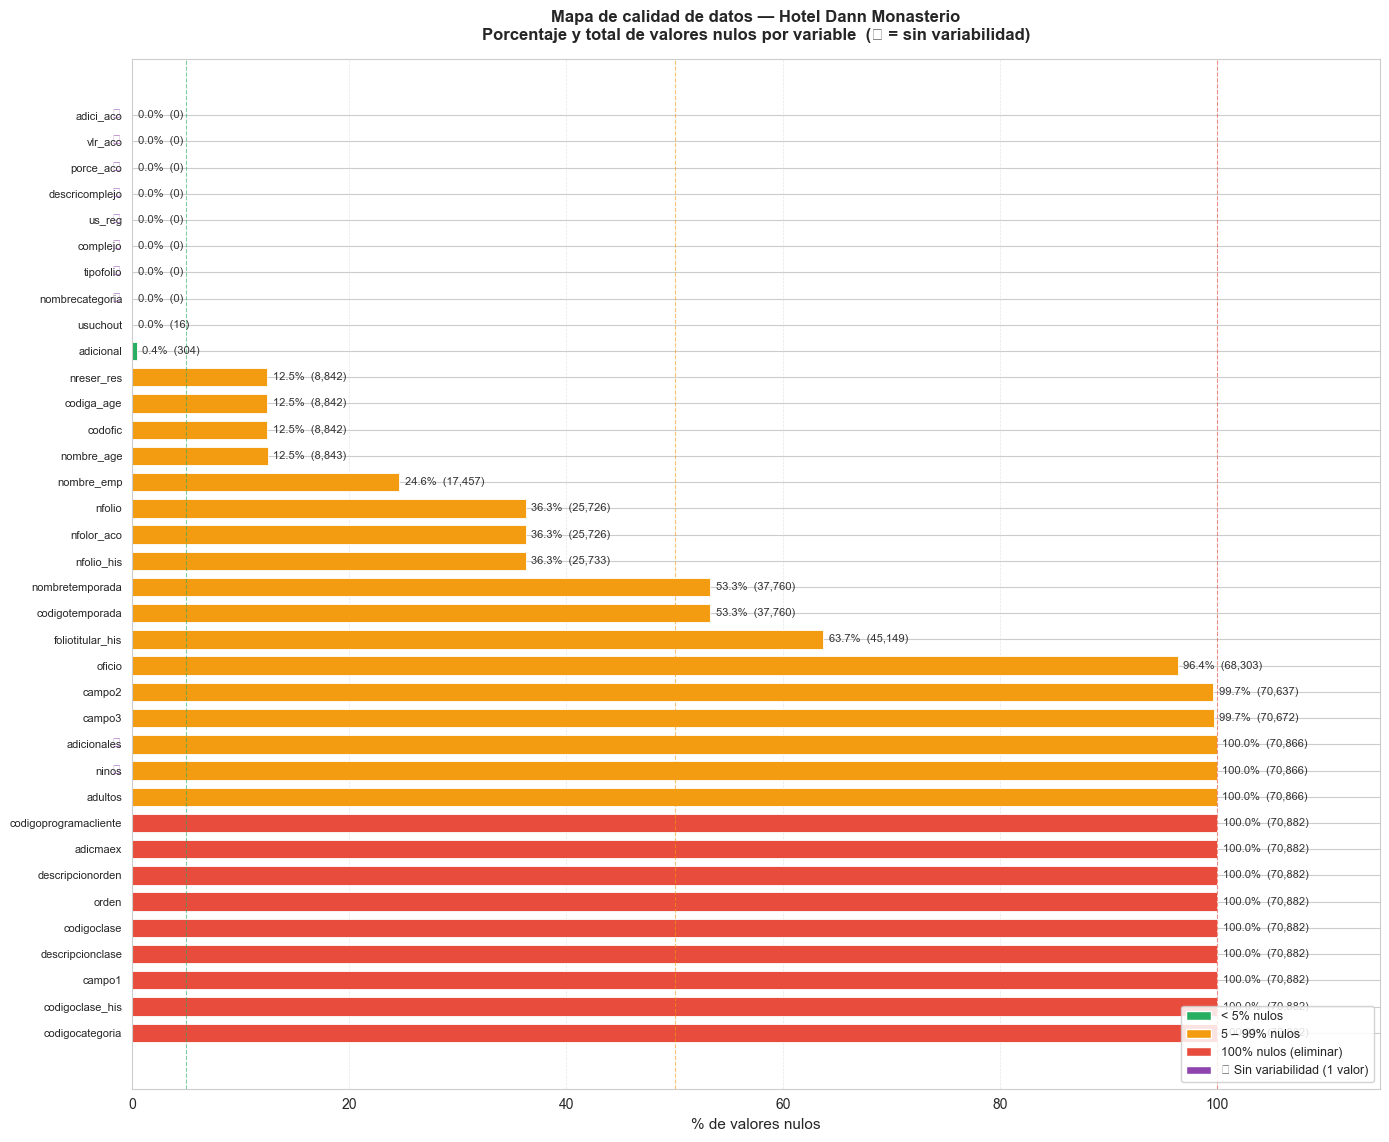


=== Resumen de calidad de datos ===
  Total variables            : 79
  Variables sin ningun nulo  : 51
  Variables con algun nulo   : 28
  Variables 100% nulas       : 9
  Variables sin variabilidad : 10

--- Variables con nulos (desc) ---
             Variable  Nulos  % Nulos  Valores unicos
     descripcionclase  70882   100.00               0
               campo1  70882   100.00               0
      codigoclase_his  70882   100.00               0
      codigocategoria  70882   100.00               0
             adicmaex  70882   100.00               0
     descripcionorden  70882   100.00               0
                orden  70882   100.00               0
          codigoclase  70882   100.00               0
codigoprogramacliente  70882   100.00               0
          adicionales  70866    99.98               1
                ninos  70866    99.98               1
              adultos  70866    99.98               2
               campo3  70672    99.70             106
  

In [41]:
# ── Mapa de calidad de datos: nulos + variabilidad ────────────────────────

# --- Tabla base -----------------------------------------------------------
nulos_abs  = df.isnull().sum()
nulos_pct  = (nulos_abs / len(df) * 100).round(2)
n_unicos   = df.nunique(dropna=True)

calidad = pd.DataFrame({
    "variable"        : df.columns,
    "nulos_total"     : nulos_abs.values,
    "nulos_pct"       : nulos_pct.values,
    "valores_unicos"  : n_unicos.values,
    "sin_variabilidad": (n_unicos == 1).values,
}).sort_values("nulos_pct", ascending=True).reset_index(drop=True)

# Solo columnas con al menos 1 nulo o sin variabilidad
calidad_plot = calidad[
    (calidad["nulos_pct"] > 0) | calidad["sin_variabilidad"]
].copy()

print(f"Variables con algún problema de calidad: {len(calidad_plot)} / {len(calidad)}")

# --- Colores por rango de nulos -------------------------------------------
def color_barra(pct):
    if pct == 100:  return "#e74c3c"  # rojo: columna vacía
    if pct >= 5:    return "#f39c12"  # naranja: nulos significativos
    return              "#27ae60"    # verde: pocos nulos (< 5 %)

colores = [color_barra(p) for p in calidad_plot["nulos_pct"]]

# --- Figura ---------------------------------------------------------------
n_vars = len(calidad_plot)
alto   = max(10, n_vars * 0.32)

fig, ax = plt.subplots(figsize=(14, alto))

bars = ax.barh(
    calidad_plot["variable"],
    calidad_plot["nulos_pct"],
    color=colores,
    edgecolor="white",
    linewidth=0.6,
    height=0.7,
)

# Etiqueta: porcentaje + conteo absoluto
for bar, (_, row) in zip(bars, calidad_plot.iterrows()):
    w     = bar.get_width()
    label = f"{w:.1f}%  ({int(row['nulos_total']):,})"
    ax.text(
        w + 0.5, bar.get_y() + bar.get_height() / 2,
        label, va="center", ha="left", fontsize=8, color="#333333"
    )
    # Marcar columnas sin variabilidad con estrella morada
    if row["sin_variabilidad"]:
        ax.text(
            -1, bar.get_y() + bar.get_height() / 2,
            "\u2605", va="center", ha="right", fontsize=9,
            color="#8e44ad", fontweight="bold"
        )

# Límites y etiquetas
ax.set_xlim(0, 115)
ax.set_xlabel("% de valores nulos", fontsize=11)
ax.set_title(
    "Mapa de calidad de datos — Hotel Dann Monasterio\n"
    "Porcentaje y total de valores nulos por variable  (\u2605 = sin variabilidad)",
    fontsize=12, fontweight="bold", pad=14
)

# Líneas de referencia
ax.axvline(5,   color="#27ae60", linestyle="--", linewidth=0.8, alpha=0.6, label="Umbral 5%")
ax.axvline(50,  color="#f39c12", linestyle="--", linewidth=0.8, alpha=0.6, label="Umbral 50%")
ax.axvline(100, color="#e74c3c", linestyle="--", linewidth=0.8, alpha=0.6, label="100% vacía")

# Leyenda
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor="#27ae60", label="< 5% nulos"),
    Patch(facecolor="#f39c12", label="5 – 99% nulos"),
    Patch(facecolor="#e74c3c", label="100% nulos (eliminar)"),
    Patch(facecolor="#8e44ad", label="\u2605 Sin variabilidad (1 valor)"),
]
ax.legend(handles=leyenda, loc="lower right", fontsize=9, framealpha=0.85)

ax.tick_params(axis='y', labelsize=8)
ax.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.5)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / "00_calidad_datos.png", bbox_inches='tight', dpi=150)
plt.show()

# --- Tabla resumen -----------------------------------------------------------
print("\n=== Resumen de calidad de datos ===")
print(f"  Total variables            : {len(df.columns)}")
print(f"  Variables sin ningun nulo  : {(nulos_abs == 0).sum()}")
print(f"  Variables con algun nulo   : {(nulos_abs > 0).sum()}")
print(f"  Variables 100% nulas       : {(nulos_pct == 100).sum()}")
print(f"  Variables sin variabilidad : {(n_unicos == 1).sum()}")
print("\n--- Variables con nulos (desc) ---")
tabla = calidad_plot[calidad_plot["nulos_pct"] > 0][
    ["variable", "nulos_total", "nulos_pct", "valores_unicos"]
].sort_values("nulos_pct", ascending=False)
tabla.columns = ["Variable", "Nulos", "% Nulos", "Valores unicos"]
print(tabla.to_string(index=False))


## Estadísticas descriptivas

Variables numéricas:

In [42]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
consecut,70882.0,1.350176e+05,1.169362e+04,114472.0,1.249772e+05,134818.5,1.451890e+05,1.553030e+05
codigoclase_his,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nrohab_hab_his,70882.0,1.907474e+02,4.666138e+01,102.0,2.010000e+02,211.0,2.230000e+02,2.320000e+02
foliotitular_his,25733.0,1.110565e+05,1.030721e+04,93076.0,1.018390e+05,111129.0,1.200970e+05,1.286550e+05
nfolio_his,45149.0,1.107387e+05,1.028806e+04,93022.0,1.016920e+05,110424.0,1.199280e+05,1.286550e+05
codigoprogramacliente,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
registro,70882.0,9.125263e+04,7.550312e+03,78039.0,8.475200e+04,91155.5,9.775600e+04,1.044620e+05
nfolio,45156.0,1.107397e+05,1.028758e+04,93022.0,1.016935e+05,110429.5,1.199262e+05,1.286550e+05
porce_aco,70882.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00
vlr_aco,70882.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00


Variables categóricas (`object`):

In [43]:
df.describe(include=[object]).T

,count,unique,top,freq
fecha,70882,2098,2024.03.29,128
codigp_pla_reg,70882,18,NBRCX,36512
codigp_pla,70882,19,NBRCX,36526
codsegmento,70882,12,ME,21027
codmotivacion,70882,40,TRA,18781
ident_aco,70882,33032,94476603,494
tdcto_aco_his,70882,9,CE,44883
clasi_aco_his,70882,2,A,70004
idn_aco_his,70882,3,T,45149
nombre_aco,70882,32851,MOLINA GALLARDO JORGE MAURICIO,494


## Variables seleccionadas para el proyecto

Después del perfilado, seleccionamos las 36 variables que efectivamente usaremos en el análisis exploratorio y descriptivo. Las demás se descartan por estar 100% vacías, no tener variabilidad o ser redundantes con su versión histórica.

In [44]:
VARS_PROYECTO = [
    # Tiempo
    "fecha", "fllega_aco", "fsalid_aco", "fcheckout", "fechasischin",
    # Segmento y motivación
    "codsegmento", "codmotivacion",
    # Plan tarifario
    "codigp_pla", "descri_pla", "alimen_pla", "tarifa", "adicional",
    # Temporada
    "codigotemporada", "nombretemporada",
    # Canal / agencia
    "nombre_age", "codiga_age", "nombre_emp",
    # Habitación
    "tiphab_tip", "clahab_clh", "nrohab_hab",
    # Huésped
    "edad_aco", "sexo_aco", "nacionalidad", "clasi_aco", "idn_aco", "incognito", "ident_aco",
    # Ingresos
    "valorplan", "ivaplan", "servicioplan",
    "valorconsumoadicional", "ivaconsumoadicional", "servicioconsumoadicional",
    "totalconsumosplan", "totalconsumosadicional",
    # Folio / reserva
    "numvoucher", "nreser_res", "folio_titular",
]

print(f"Total variables seleccionadas: {len(VARS_PROYECTO)} de {df.shape[1]}")

# Verificación: todas existen en el DataFrame
faltantes = [v for v in VARS_PROYECTO if v not in df.columns]
print(f"Variables faltantes: {faltantes if faltantes else 'ninguna'}")

Total variables seleccionadas: 38 de 79
Variables faltantes: ninguna


Subset del DataFrame con sólo las variables seleccionadas:

In [45]:
df_proyecto = df[VARS_PROYECTO].copy()
df_proyecto.head()

,fecha,fllega_aco,fsalid_aco,fcheckout,fechasischin,codsegmento,codmotivacion,codigp_pla,descri_pla,alimen_pla,tarifa,adicional,codigotemporada,nombretemporada,nombre_age,codiga_age,nombre_emp,tiphab_tip,clahab_clh,nrohab_hab,edad_aco,sexo_aco,nacionalidad,clasi_aco,idn_aco,incognito,ident_aco,valorplan,ivaplan,servicioplan,valorconsumoadicional,ivaconsumoadicional,servicioconsumoadicional,totalconsumosplan,totalconsumosadicional,numvoucher,nreser_res,folio_titular
0,2020.06.01,2020-06-01,2020-06-02,2020-06-02,2020-06-10 18:56:00.000,COR,CCE,CORP1,CORPORATIVO 1,S,183800.0,70000.0,NaN,NaN,NaN,NaN,J RESTREPO EQUIPHOS SAS,SE,SG,207,36,M,COL,A,T,N,1075659763,190000.0,36100.0,0.0,0.0,0.0,0.0,226100.0,0.0,75523,NaN,93022
1,2020.06.10,2020-06-10,2020-06-11,2020-06-11,2020-06-11 15:29:00.000,COR,CCE,CORP1,CORPORATIVO 1,S,183800.0,70000.0,NaN,NaN,NaN,NaN,J RESTREPO EQUIPHOS SAS,SE,SG,207,36,M,COL,A,T,N,1075659763,190000.0,36100.0,0.0,0.0,0.0,0.0,226100.0,0.0,75524,NaN,93023
2,2020.06.11,2020-06-11,2020-06-12,2020-06-12,2020-06-12 07:16:00.000,COR,CCE,CORP1,CORPORATIVO 1,S,183800.0,70000.0,NaN,NaN,NaN,NaN,KELLOGG DE COLOMBIA S.A.,SE,SG,207,126,M,COL,A,T,N,1112099164,190000.0,36100.0,0.0,0.0,0.0,0.0,226100.0,0.0,75525,NaN,93025
3,2020.07.02,2020-07-02,2020-07-18,2020-07-18,2020-07-03 08:19:59.999,COR,CCE,CORP1,CORPORATIVO 1,S,183800.0,70000.0,NaN,NaN,AVIATUR,AVIA,CEMENTOS ARGOS S.A,SE,SG,207,45,M,COL,A,T,N,16842997,190000.0,0.0,0.0,0.0,0.0,0.0,190000.0,0.0,75526,70660.0,93030
4,2020.07.03,2020-07-02,2020-07-18,2020-07-18,2020-07-03 08:19:59.999,COR,CCE,CORP1,CORPORATIVO 1,S,183800.0,70000.0,NaN,NaN,AVIATUR,AVIA,CEMENTOS ARGOS S.A,SE,SG,207,45,M,COL,A,T,N,16842997,190000.0,0.0,0.0,0.0,0.0,0.0,190000.0,0.0,75526,70660.0,93030


## Validación de estado de las variables seleccionadas.

validamos el porcentaje de nullos.

In [46]:
nulos = df_proyecto.isnull().sum()
porc  = (nulos / len(df_proyecto) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "nulos": nulos,
    "% nulos": porc,
    "no_nulos": df_proyecto.notnull().sum()
}).sort_values("% nulos", ascending=False)

#resumen_nulos
print(resumen_nulos.to_string())

                          nulos  % nulos  no_nulos
nombretemporada           37760    53.27     33122
codigotemporada           37760    53.27     33122
nombre_emp                17457    24.63     53425
nombre_age                 8843    12.48     62039
nreser_res                 8842    12.47     62040
codiga_age                 8842    12.47     62040
adicional                   304     0.43     70578
fechasischin                  0     0.00     70882
codsegmento                   0     0.00     70882
fsalid_aco                    0     0.00     70882
fllega_aco                    0     0.00     70882
fecha                         0     0.00     70882
fcheckout                     0     0.00     70882
alimen_pla                    0     0.00     70882
tarifa                        0     0.00     70882
codigp_pla                    0     0.00     70882
descri_pla                    0     0.00     70882
tiphab_tip                    0     0.00     70882
clahab_clh                    0

## Distribución de variables categóricas clave

En lugar de una sola variable objetivo, aquí exploramos varias variables categóricas estratégicas con `countplot`.

### Distribución de reservas por segmento comercial

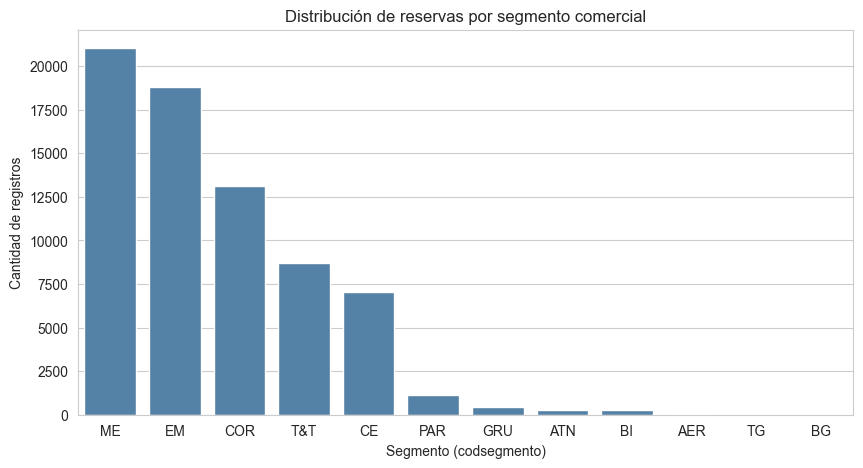

codsegmento
ME     29.66
EM     26.50
COR    18.54
T&T    12.28
CE      9.97
PAR     1.58
GRU     0.60
ATN     0.39
BI      0.38
AER     0.08
TG      0.01
BG      0.01
Name: proportion, dtype: float64

In [47]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_proyecto,
    x="codsegmento",
    order=df_proyecto["codsegmento"].value_counts().index,
    color="steelblue"
)
plt.title("Distribución de reservas por segmento comercial")
plt.xlabel("Segmento (codsegmento)")
plt.ylabel("Cantidad de registros")
plt.savefig(FIG_DIR / "01_segmento_comercial.png", bbox_inches='tight', dpi=150)
plt.show()

df_proyecto["codsegmento"].value_counts(normalize=True).mul(100).round(2)

### Distribución por temporada

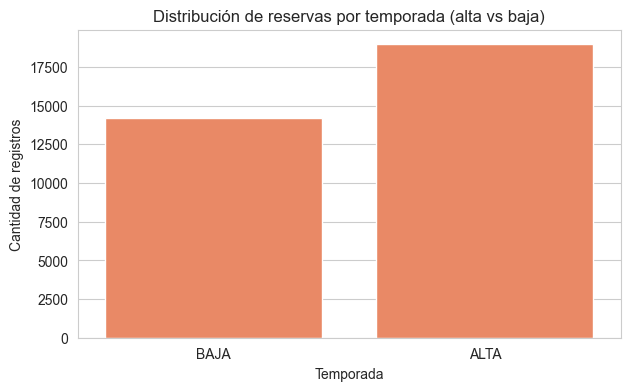

Porcentaje de nulos en 'nombretemporada': 53.27163454755791 %


In [48]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df_proyecto.dropna(subset=["nombretemporada"]),
    x="nombretemporada",
    color="coral"
)
plt.title("Distribución de reservas por temporada (alta vs baja)")
plt.xlabel("Temporada")
plt.ylabel("Cantidad de registros")
plt.savefig(FIG_DIR / "02_temporada.png", bbox_inches='tight', dpi=150)
plt.show()

print("Porcentaje de nulos en 'nombretemporada':",
      df_proyecto["nombretemporada"].isna().mean()*100, "%")

### Top 10 canales / agencias de reserva

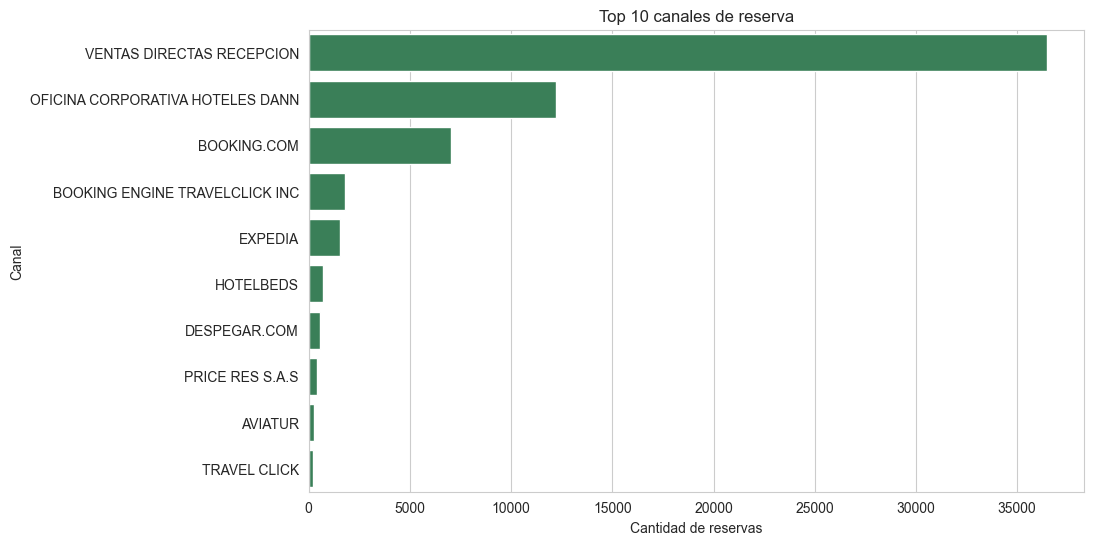

nombre_age
VENTAS DIRECTAS RECEPCION           36461
OFICINA CORPORATIVA HOTELES DANN    12198
BOOKING.COM                          7031
BOOKING ENGINE TRAVELCLICK INC       1800
EXPEDIA                              1570
HOTELBEDS                             722
DESPEGAR.COM                          579
PRICE RES S.A.S                       396
AVIATUR                               268
TRAVEL CLICK                          197
Name: count, dtype: int64

In [49]:
top10_canales = df_proyecto["nombre_age"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top10_canales.values,
    y=top10_canales.index,
    color="seagreen"
)
plt.title("Top 10 canales de reserva")
plt.xlabel("Cantidad de reservas")
plt.ylabel("Canal")
plt.savefig(FIG_DIR / "03_top10_canales.png", bbox_inches='tight', dpi=150)
plt.show()

top10_canales

### Distribución por tipo de habitación

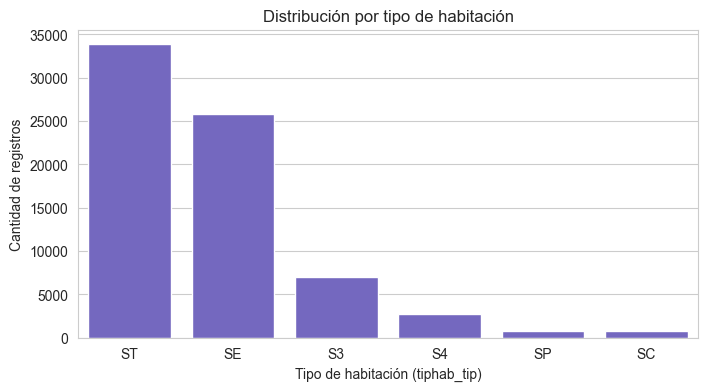

In [50]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df_proyecto,
    x="tiphab_tip",
    order=df_proyecto["tiphab_tip"].value_counts().index,
    color="slateblue"
)
plt.title("Distribución por tipo de habitación")
plt.xlabel("Tipo de habitación (tiphab_tip)")
plt.ylabel("Cantidad de registros")
plt.savefig(FIG_DIR / "04_tipo_habitacion.png", bbox_inches='tight', dpi=150)
plt.show()

### Distribución por sexo del huésped

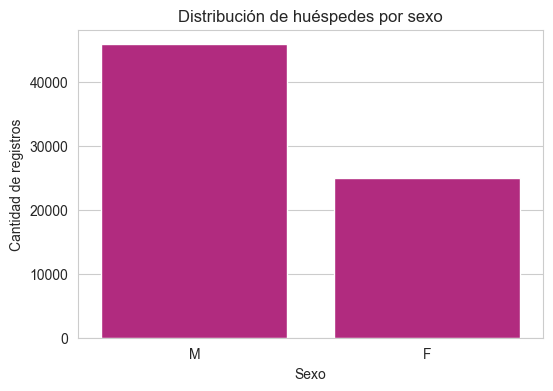

In [51]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df_proyecto,
    x="sexo_aco",
    color="mediumvioletred"
)
plt.title("Distribución de huéspedes por sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad de registros")
plt.savefig(FIG_DIR / "05_sexo_huesped.png", bbox_inches='tight', dpi=150)
plt.show()

## Histograma de variables numéricas clave

El proyecto base aplicaba `df.hist()` a todas las columnas; aquí seleccionamos sólo las variables numéricas relevantes para evitar 70+ subgráficas.

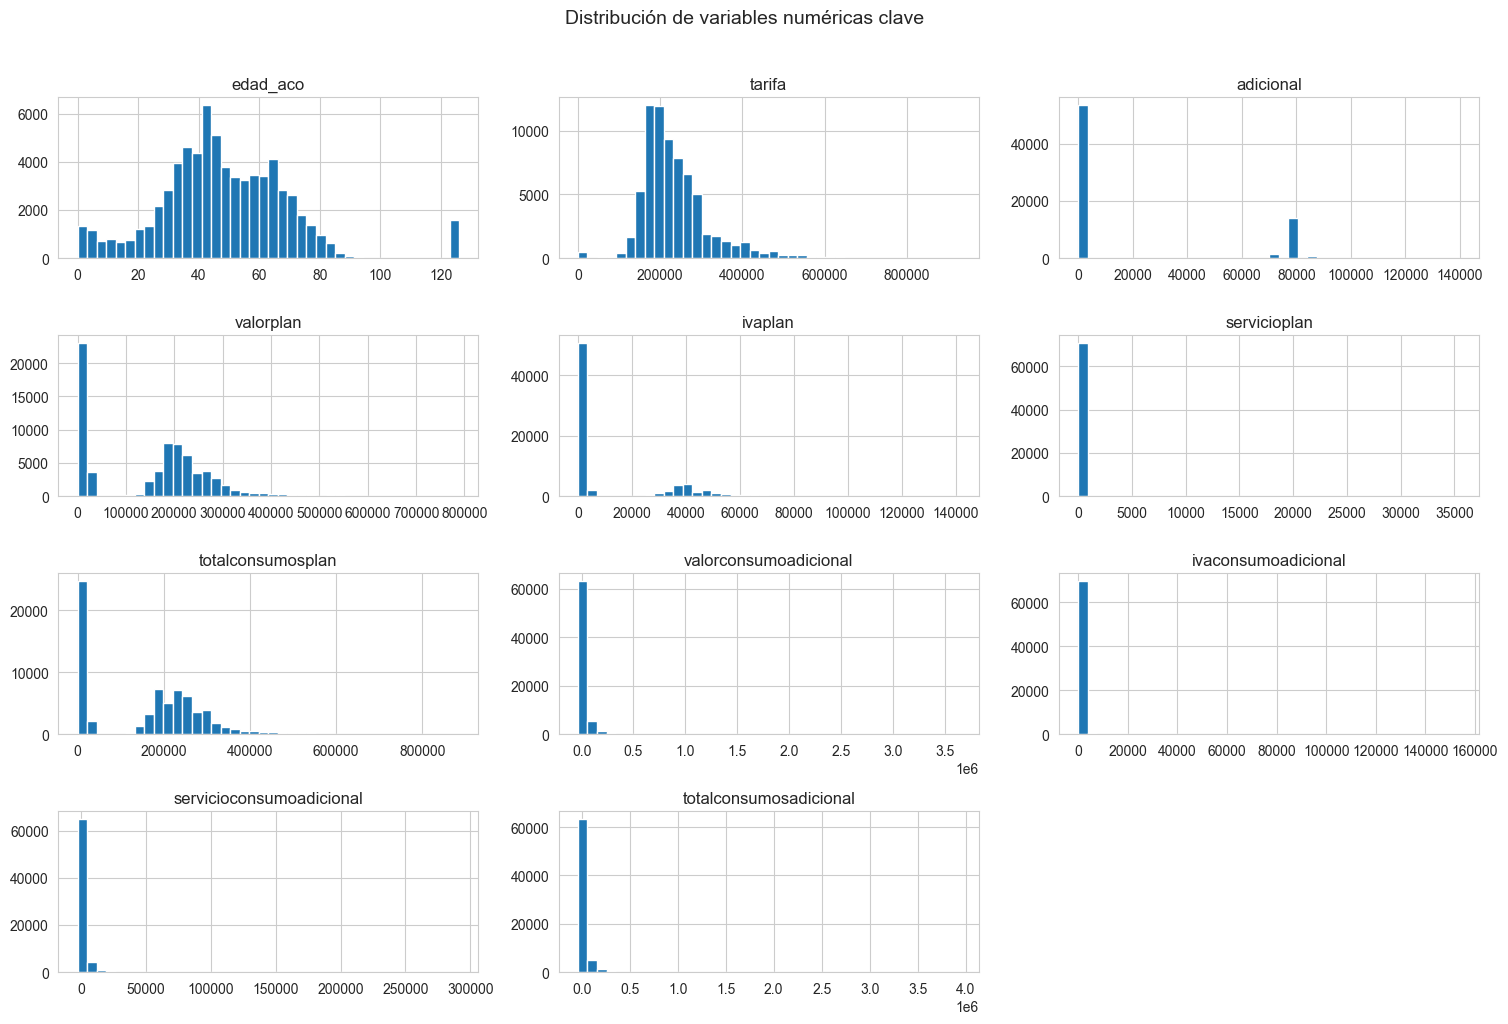

In [52]:
numericas_clave = [
    "edad_aco",
    "tarifa",
    "adicional",
    "valorplan",
    "ivaplan",
    "servicioplan",
    "totalconsumosplan",
    "valorconsumoadicional",
    "ivaconsumoadicional",
    "servicioconsumoadicional",
    "totalconsumosadicional",
]

df_proyecto[numericas_clave].hist(bins=40, figsize=(15, 10))
plt.suptitle("Distribución de variables numéricas clave", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_histogramas_numericas.png", bbox_inches='tight', dpi=150)
plt.show()

## Análisis temporal preliminar

Evolución del volumen de reservas a lo largo del periodo. La columna `fechasischin` es la fecha de llegada del huésped.

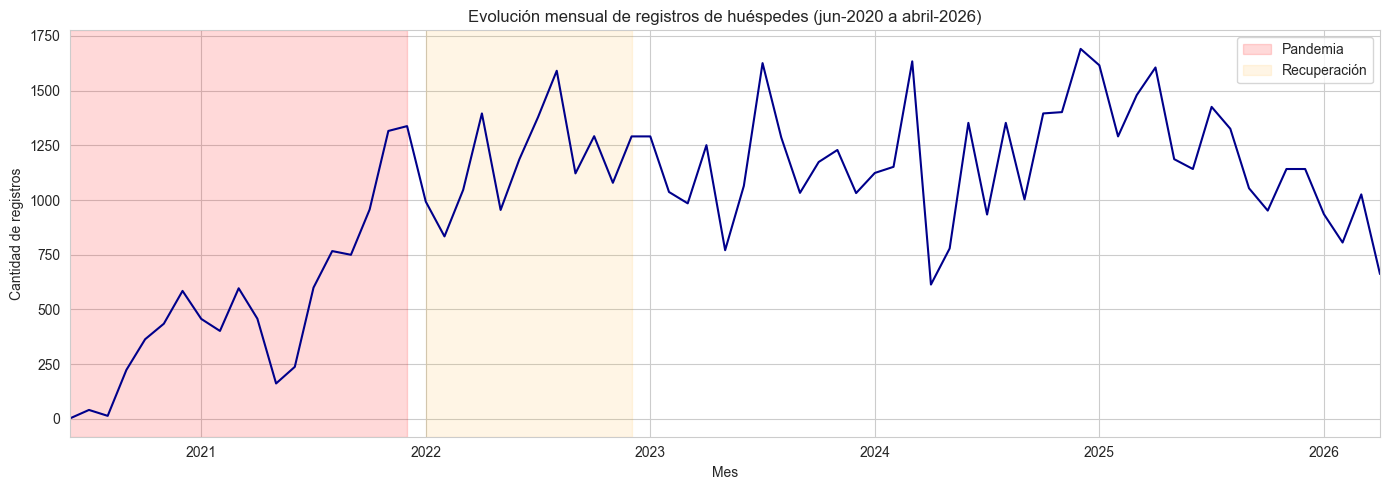

In [53]:
# Asegurar que fechasischin es datetime
df_proyecto["fechasischin"] = pd.to_datetime(df_proyecto["fechasischin"], errors="coerce")
df_proyecto["anio_mes"] = df_proyecto["fechasischin"].dt.to_period("M").dt.to_timestamp()

reservas_mensuales = df_proyecto.groupby("anio_mes").size()

plt.figure(figsize=(14, 5))
reservas_mensuales.plot(color="darkblue")
plt.title("Evolución mensual de registros de huéspedes (jun-2020 a abril-2026)")
plt.xlabel("Mes")
plt.ylabel("Cantidad de registros")
plt.axvspan("2020-03-01", "2021-12-31", alpha=0.15, color="red", label="Pandemia")
plt.axvspan("2022-01-01", "2022-12-31", alpha=0.10, color="orange", label="Recuperación")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "07_serie_temporal_mensual.png", bbox_inches='tight', dpi=150)
plt.show()

## Matriz de correlación (variables numéricas)

Buscamos relaciones lineales entre las variables numéricas clave.

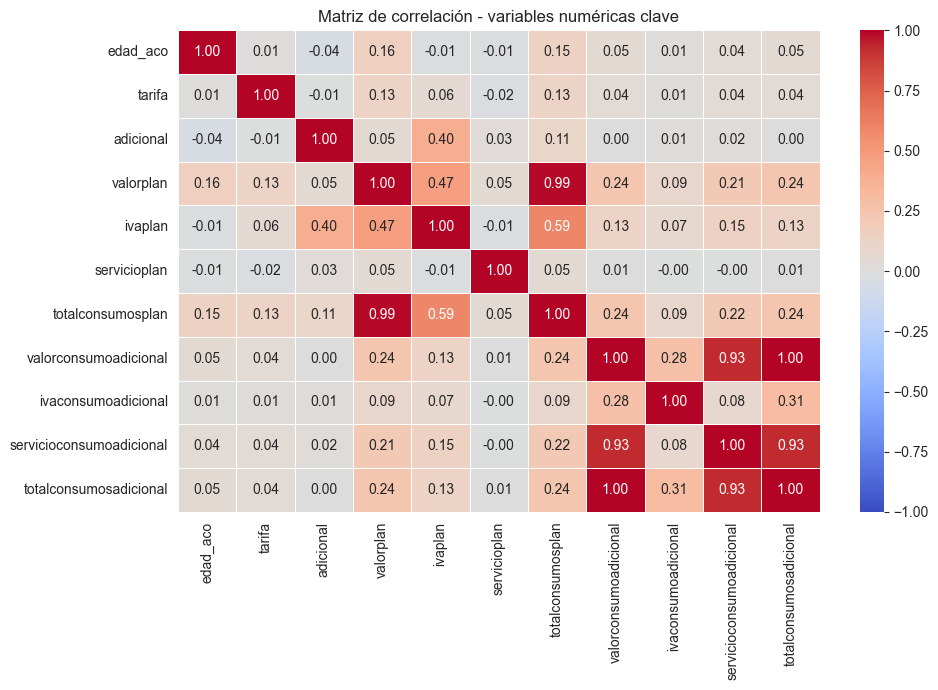

In [54]:
correlacion = df_proyecto[numericas_clave].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Matriz de correlación - variables numéricas clave")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_correlacion.png", bbox_inches='tight', dpi=150)
plt.show()

## Variables más correlacionadas con `totalconsumosplan`

Tomamos `totalconsumosplan` (ingreso total del plan) como variable de interés principal.

In [55]:
correlacion["totalconsumosplan"].sort_values(ascending=False)

totalconsumosplan           1.000000
valorplan                   0.990704
ivaplan                     0.588643
totalconsumosadicional      0.239775
valorconsumoadicional       0.239118
servicioconsumoadicional    0.217235
edad_aco                    0.147442
tarifa                      0.125986
adicional                   0.105135
ivaconsumoadicional         0.092362
servicioplan                0.049071
Name: totalconsumosplan, dtype: float64

## Variables más correlacionadas con `totalconsumoadicional`

Tomamos `totalconsumoadicional` (ingreso total lo adicional de la reserva) como variable de interés principal

In [56]:
correlacion["totalconsumosadicional"].sort_values(ascending=False)

totalconsumosadicional      1.000000
valorconsumoadicional       0.999355
servicioconsumoadicional    0.927152
ivaconsumoadicional         0.306579
totalconsumosplan           0.239775
valorplan                   0.239194
ivaplan                     0.131554
edad_aco                    0.049179
tarifa                      0.042091
servicioplan                0.005591
adicional                   0.004603
Name: totalconsumosadicional, dtype: float64

## Deteccion de valores atipicos

Boxplots de las variables numericas clave. El analisis diferencia entre **variabilidad natural de negocio** y **errores de captura que deben corregirse**:

### Errores de dato que requieren correccion

- **`edad_aco`**: valores de 0 y 126 anos (imposibles fisiologicamente). Errores de captura o registros administrativos sin huesped real. Se imputaran con la mediana del segmento.
- **`valorconsumoadicional`**, **`servicioconsumoadicional`** y **`totalconsumosadicional`**: valores **negativos** son errores de registro. Un consumo adicional no puede ser negativo; si no hay consumo el valor correcto es 0. Los negativos se corregiran a 0.

### Variabilidad alta que NO es un error

- **`adicional`**, **`adicional`**, **`valorconsumoadicional`** y **`totalconsumosadicional`**: la dispersion amplia y cola derecha extendida son completamente **normales** en el negocio hotelero. Cada huesped consume a discrecion (restaurante, spa, minibar, eventos), no existe un techo natural ni valor uniforme esperado. No se aplica recorte IQR; solo se corrigen los negativos.
- **`tarifa`**: la asimetria con valores altos corresponde a suites presidenciales, tarifas corporativas y eventos grupales. Son valores reales y validos que no se eliminan para el modelo dimensional.

El tratamiento de negativos se aplica en el notebook `02_limpieza_datos.ipynb`.

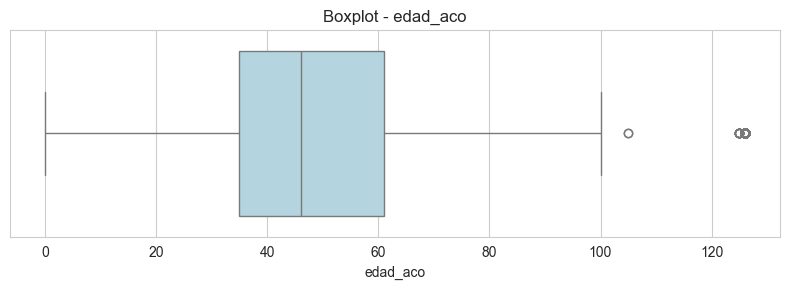

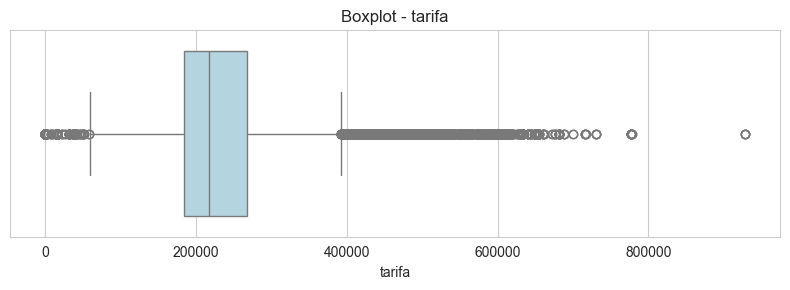

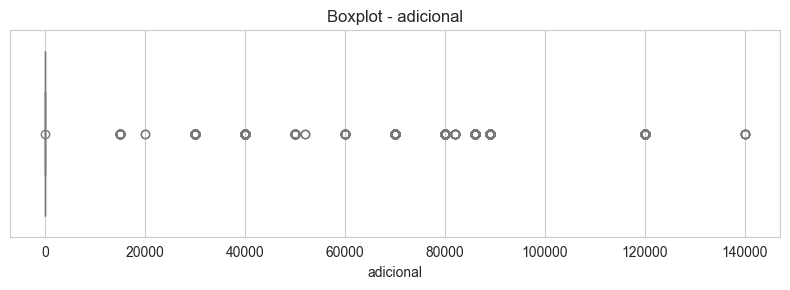

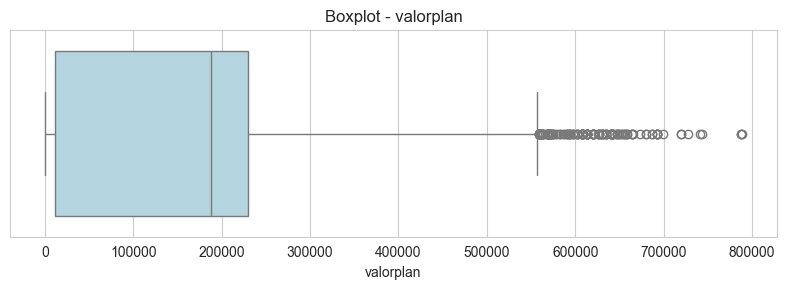

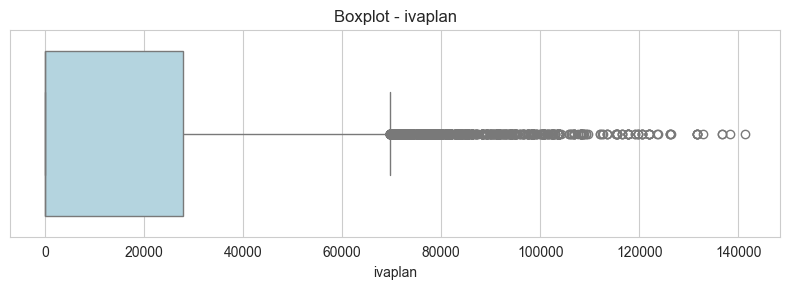

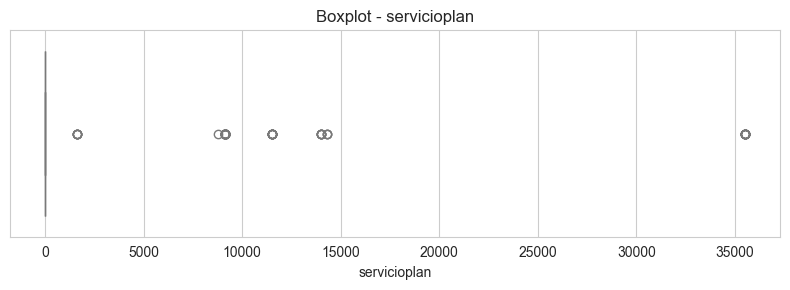

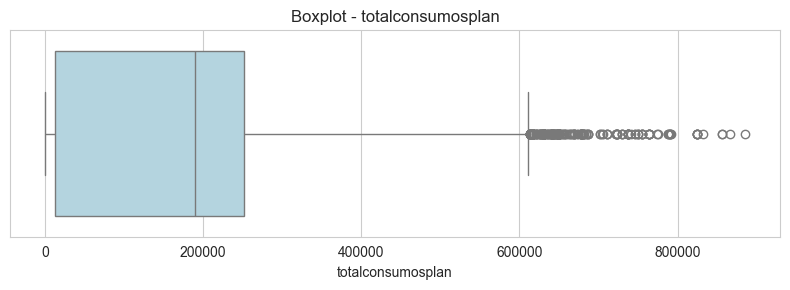

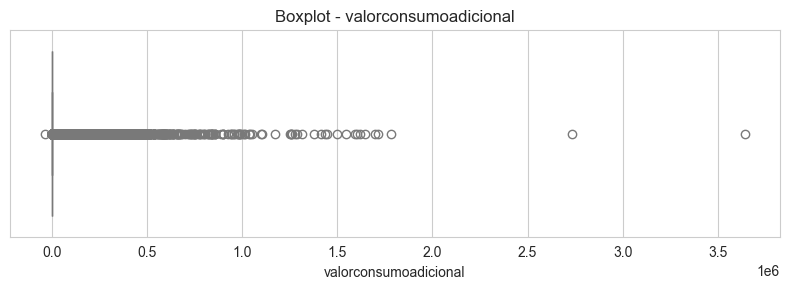

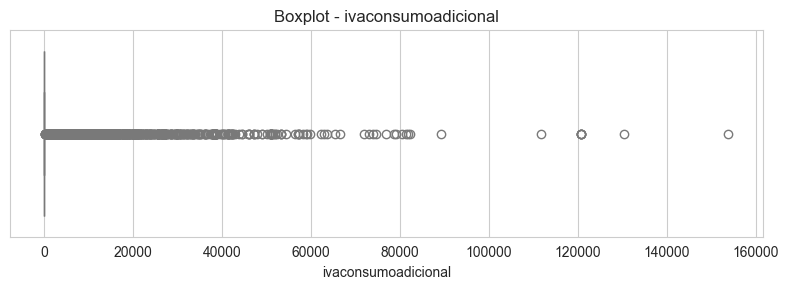

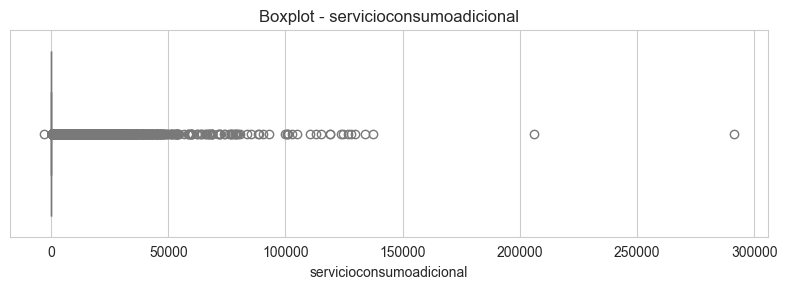

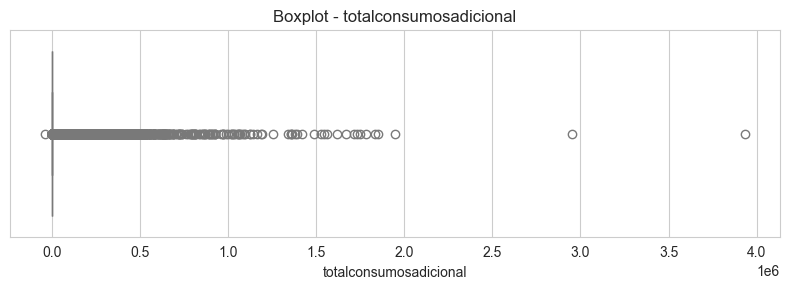

In [57]:
for col in numericas_clave:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_proyecto[col], color="lightblue")
    plt.title(f"Boxplot - {col}")
    plt.tight_layout()
    fname = f"09_boxplot_{col}.png"
    plt.savefig(FIG_DIR / fname, bbox_inches='tight', dpi=150)
    plt.show()


### Casos atípicos en `edad_aco`

Visualizamos cuántos registros tienen edades fuera del rango plausible (1-100 años):

In [58]:
edad_outliers = df_proyecto[
    (df_proyecto["edad_aco"] < 1) | (df_proyecto["edad_aco"] > 100)
]
print(f"Registros con edad fuera de rango plausible: {len(edad_outliers):,}")
edad_outliers["edad_aco"].value_counts().head(10)

Registros con edad fuera de rango plausible: 1,837


edad_aco
126    1586
0       239
125      10
105       2
Name: count, dtype: int64

## Calidad de datos: duplicados

In [59]:
duplicados = df_proyecto.duplicated().sum()
print(f"Registros duplicados (considerando todas las variables seleccionadas): {duplicados:,}")

Registros duplicados (considerando todas las variables seleccionadas): 0


Duplicados por identificación del huésped (sólo si hay varias filas con el mismo `ident_aco`, lo cual es esperable por reservas múltiples):

In [60]:
huespedes_unicos = df_proyecto["ident_aco"].nunique()
print(f"Huéspedes únicos: {huespedes_unicos:,}")
print(f"Promedio de registros por huésped: {len(df_proyecto)/huespedes_unicos:.2f}")

Huéspedes únicos: 33,032
Promedio de registros por huésped: 2.15


# Conclusiones iniciales

1. **Dimensiones del dataset**: 70,882 filas y 79 columnas en dos hojas: Hoja1 (65,534 registros, jun 2020-nov 2025) y Hoja2 (5,348 registros, nov 2025-abr 2026).

2. **Columnas vacias**: 15 columnas descartadas en notebook 02 (9 al 100% nulas, 5 al >99.5%, 1 al >90%, mas `codigotemporada` con 53.27% nulos conservada con limitacion).

3. **Variables seleccionadas**: 38 de las 79 originales en 8 categorias: tiempo, segmento, plan tarifario, temporada, canal/agencia, habitacion, huesped e ingresos.

4. **Segmentacion comercial** (12 segmentos).

5. **Canales**: RECE (52%), HDAN (18.6%), BKNG (8.8%) concentran >79% de reservas. Valida H2.

6. **Errores de dato a corregir en notebook 02**:
   - **`edad_aco`**: 0 y 126 anos -> excluir o imputar con mediana del segmento.
   - **`valorconsumoadicional`**, **`servicioconsumoadicional`** y **`totalconsumosadicional`**: negativos -> corregir a 0. Alta variabilidad y valores altos son NORMALES; cada huesped consume libremente. No se aplica recorte IQR.

7. **PII**: `ident_aco` y `nombre_aco` se anonimizaran con hash SHA-256 (notebook 02).

8. **Temporalidad**: junio 2020 - abril 2026. Efecto pandemia en 2020-2021, maximos en 2023-2024.

9. **Variables de ingreso**:
   - `totalconsumosplan` = `valorplan` + `ivaplan` + `servicioplan`
   - `totalconsumosadicional` = `valorconsumoadicional` + `ivaconsumoadicional` + `servicioconsumoadicional`
   - `ingreso_total` = `totalconsumosplan` + `totalconsumosadicional` + `tarifa` + `adicional` 
   
   Los consumos adicionales varian ampliamente por huesped; es comportamiento normal hotelero.

**Siguiente paso - notebook 02**:
- Eliminar fijar y dejar las 38 seleccionadas.
- Anonimizar PII (SHA-256 en `ident_aco`).
- Corregir negativos en `valorconsumoadicional`, `servicioconsumoadicional`, `totalconsumosadicional` a 0.
- Imputar `edad_aco` con la mediana, en los registros fuera del rango 1-100 anos.
- Calcular variables derivadas: `duracion_estancia`, `lead_time`, `anio`, `mes`, `trimestre`, `dia_semana`, `ingreso_total`, `rango_edad`.
- Exportar a `data/processed/reservas_clean.parquet`.


## Figuras exportadas — Evidencia del EDA

Todas las gráficas generadas en este notebook se han guardado automáticamente en `reports/figures/` para documentación y evidencia académica.


In [61]:
# ── Inventario de figuras exportadas ──────────────────────────────────────
figuras = sorted(FIG_DIR.glob("*.png"))
print(f"Total de figuras guardadas en reports/figures/: {len(figuras)}")
for f in figuras:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size_kb:>6.1f} KB")


Total de figuras guardadas en reports/figures/: 20
  00_calidad_datos.png                           218.0 KB
  01_segmento_comercial.png                       41.5 KB
  02_temporada.png                                32.2 KB
  03_top10_canales.png                            54.6 KB
  04_tipo_habitacion.png                          32.6 KB
  05_sexo_huesped.png                             23.3 KB
  06_histogramas_numericas.png                   135.5 KB
  07_serie_temporal_mensual.png                  116.0 KB
  08_correlacion.png                             172.4 KB
  09_boxplot_adicional.png                        15.0 KB
  09_boxplot_edad_aco.png                         13.7 KB
  09_boxplot_ivaconsumoadicional.png              20.9 KB
  09_boxplot_ivaplan.png                          16.5 KB
  09_boxplot_servicioconsumoadicional.png         21.1 KB
  09_boxplot_servicioplan.png                     15.2 KB
  09_boxplot_tarifa.png                           14.0 KB
  09_boxplot_totalcon